# **VAE Architecture**

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ----------------------------
# Encoder Network
# ----------------------------
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),  # 28x28 -> 14x14
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # 14x14 -> 7x7
            nn.ReLU()
        )
        self.flatten = nn.Flatten()
        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)

    def forward(self, x):
        x = self.conv(x)
        x = self.flatten(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

# ----------------------------
# Decoder Network (Learned Variance)
# ----------------------------
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Linear(latent_dim, 64 * 7 * 7)
        self.deconv_base = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 7x7 -> 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(32, 32, kernel_size=4, stride=2, padding=1),  # 14x14 -> 28x28
            nn.ReLU()
        )

        # Two output heads:
        self.out_mu = nn.Conv2d(32, 1, kernel_size=3, padding=1)       # Mean image
        self.out_logvar = nn.Conv2d(32, 1, kernel_size=3, padding=1)   # Log-variance

    def forward(self, z):
        x = self.fc(z).view(-1, 64, 7, 7)
        x = self.deconv_base(x)
        mu = torch.sigmoid(self.out_mu(x))  # constrain to [0,1] pixel space
        logvar = self.out_logvar(x)         # unconstrained
        logvar = torch.clamp(logvar, min=-6.0, max=3.0)  # Clamp safely here
        return mu, logvar

# ----------------------------
# VAE Wrapper
# ----------------------------
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu_z, logvar_z = self.encoder(x)                 # encoder outputs
        z = self.reparameterize(mu_z, logvar_z)          # latent sample
        mu_x, logvar_x = self.decoder(z)                 # decoder outputs
        return mu_x, logvar_x, mu_z, logvar_z, z         # outputs needed for ELBO



In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import torchvision.utils as vutils

def get_mnist_dataloaders(batch_size=128):
    transform = transforms.Compose([transforms.ToTensor()])
    full_train_set = datasets.MNIST('./data', train=True, download=True, transform=transform)
    test_set = datasets.MNIST('./data', train=False, download=True, transform=transform)
    train_set, val_set = random_split(full_train_set, [50000, 10000])
    return (
        DataLoader(train_set, batch_size=batch_size, shuffle=True),
        DataLoader(val_set, batch_size=batch_size, shuffle=False),
        DataLoader(test_set, batch_size=batch_size, shuffle=False)
    )

def elbo_loss(x, mu_x, logvar_x, mu_z, logvar_z):
    B = x.size(0)
    x = x.view(B, -1)
    mu_x = mu_x.view(B, -1)
    logvar_x = logvar_x.view(B, -1)

    eps = 1e-6
    var = torch.exp(logvar_x) + eps  # Safe variance

    # Numerically stable Gaussian log-likelihood
    recon_loss = 0.5 * (
        torch.log(2 * torch.pi * var) + ((x - mu_x) ** 2) / var
    )
    recon_loss = torch.sum(recon_loss, dim=1)

    # KL divergence
    kl_div = -0.5 * torch.sum(1 + logvar_z - mu_z.pow(2) - logvar_z.exp(), dim=1)

    return torch.mean(recon_loss + kl_div)




In [18]:
import torch
import matplotlib.pyplot as plt

def train_vae(model, train_loader, val_loader, optimizer,
                                   num_epochs=100, patience=10, device='cuda'):

    model = model.to(device)
    train_elbo, val_elbo = [], []

    best_val_elbo = float('-inf')
    epochs_without_improvement = 0

    for epoch in range(1, num_epochs + 1):
        model.train()
        total_train_loss = 0
        for x_batch, _ in train_loader:
            x_batch = x_batch.to(device)
            optimizer.zero_grad()
            mu_x, logvar_x, mu_z, logvar_z, _ = model(x_batch)
            loss = elbo_loss(x_batch, mu_x, logvar_x, mu_z, logvar_z)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_elbo.append(-avg_train_loss)

        # --- Validation ---
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for x_val, _ in val_loader:
                x_val = x_val.to(device)
                mu_x, logvar_x, mu_z, logvar_z, _ = model(x_val)
                loss = elbo_loss(x_val, mu_x, logvar_x, mu_z, logvar_z)
                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        val_elbo.append(-avg_val_loss)

        print(f"Epoch {epoch:02d} | Train ELBO: {-avg_train_loss:.4f} | Val ELBO: {-avg_val_loss:.4f}")

        # Early stopping logic
        if -avg_val_loss > best_val_elbo:
            best_val_elbo = -avg_val_loss
            epochs_without_improvement = 0
            best_model_state = model.state_dict()
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Stopping early at epoch {epoch} due to no improvement in validation ELBO.")
            break

    # Restore best model
    model.load_state_dict(best_model_state)

    # Plot ELBO
    plt.plot(train_elbo, label='Train ELBO')
    plt.plot(val_elbo, label='Validation ELBO')
    plt.xlabel('Epoch')
    plt.ylabel('ELBO')
    plt.legend()
    plt.title('ELBO vs Epoch')
    plt.show()

    return train_elbo, val_elbo



In [19]:
import torchvision.utils as vutils

def test_vae_reconstruction_and_generation(model, test_loader, device='cuda'):
    model.eval()
    model = model.to(device)

    # Get a single batch from test set
    x_test, _ = next(iter(test_loader))
    x_test = x_test[:32].to(device)  # use only first 32 for display
    with torch.no_grad():
        mu_z, logvar_z = model.encoder(x_test)
        z = model.reparameterize(mu_z, logvar_z)
        mu_x, logvar_x = model.decoder(z)
        std_x = torch.exp(0.5 * logvar_x)
        recon_x = mu_x + std_x * torch.randn_like(std_x)  # sample x' ~ N(mu, sigma²)

    # Arrange originals and reconstructions side-by-side
    grid = torch.cat([x_test.cpu(), recon_x.cpu()], dim=0)
    grid_img = vutils.make_grid(grid, nrow=8, pad_value=1)

    plt.figure(figsize=(8, 8))
    plt.axis('off')
    plt.title('Top: Original | Bottom: Reconstruction')
    plt.imshow(grid_img.permute(1, 2, 0), cmap='gray')
    plt.show()

def generate_from_prior(model, num_samples=64, device='cuda'):
    model.eval()
    model = model.to(device)

    with torch.no_grad():
        z = torch.randn(num_samples, model.encoder.fc_mu.out_features).to(device)
        mu_x, logvar_x = model.decoder(z)
        std_x = torch.exp(0.5 * logvar_x)
        gen_x = mu_x + std_x * torch.randn_like(std_x)

    grid_img = vutils.make_grid(gen_x.cpu(), nrow=8, pad_value=1)

    plt.figure(figsize=(8, 8))
    plt.axis('off')
    plt.title('Generated Samples from Prior')
    plt.imshow(grid_img.permute(1, 2, 0), cmap='gray')
    plt.show()


Epoch 01 | Train ELBO: 250.3354 | Val ELBO: 819.0869
Epoch 02 | Train ELBO: 928.1015 | Val ELBO: 1016.2878
Epoch 03 | Train ELBO: 1069.0502 | Val ELBO: 1106.1418
Epoch 04 | Train ELBO: 1128.7334 | Val ELBO: 1147.5697
Epoch 05 | Train ELBO: 1160.5631 | Val ELBO: 1171.2995
Epoch 06 | Train ELBO: 1182.0916 | Val ELBO: 1190.7640
Epoch 07 | Train ELBO: 1199.0626 | Val ELBO: 1205.9934
Epoch 08 | Train ELBO: 1213.0085 | Val ELBO: 1217.7538
Epoch 09 | Train ELBO: 1224.1181 | Val ELBO: 1228.3950
Epoch 10 | Train ELBO: 1233.3311 | Val ELBO: 1235.3105
Epoch 11 | Train ELBO: 1240.7442 | Val ELBO: 1242.6904
Epoch 12 | Train ELBO: 1247.1638 | Val ELBO: 1247.6524
Epoch 13 | Train ELBO: 1252.8560 | Val ELBO: 1253.1870
Epoch 14 | Train ELBO: 1257.3714 | Val ELBO: 1257.0311
Epoch 15 | Train ELBO: 1261.8039 | Val ELBO: 1260.7059
Epoch 16 | Train ELBO: 1265.6224 | Val ELBO: 1260.6664
Epoch 17 | Train ELBO: 1268.7361 | Val ELBO: 1266.8558
Epoch 18 | Train ELBO: 1272.1836 | Val ELBO: 1269.8038
Epoch 19 | Tr

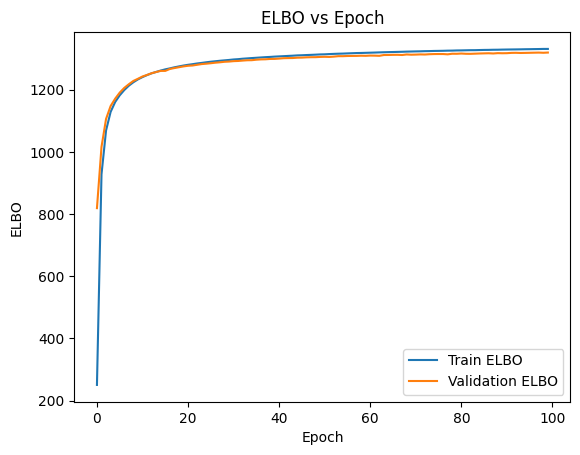

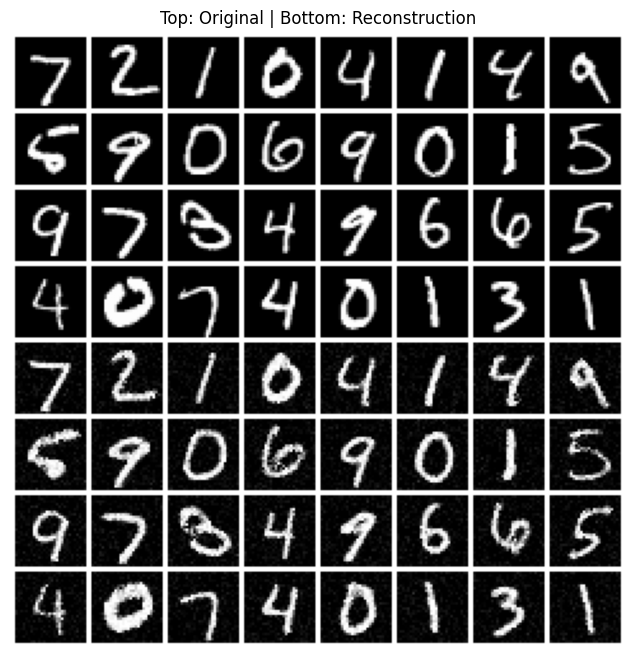

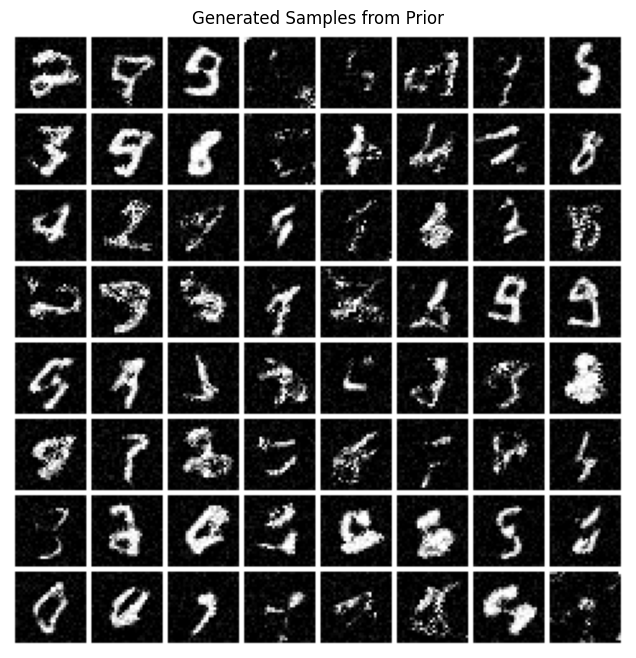

In [20]:
torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
latent_dim = 20
batch_size = 128

train_loader, val_loader, test_loader = get_mnist_dataloaders(batch_size)

model = VAE(latent_dim)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

train_vae(model, train_loader, val_loader, optimizer, num_epochs=100, patience=10, device=device)
test_vae_reconstruction_and_generation(model, test_loader, device=device)
generate_from_prior(model, num_samples=64, device=device)